In [1]:
import os
import argparse
import numpy as np
import torch
import torch.optim as optim
from torchvision.transforms import Compose, Resize, InterpolationMode
from torch.utils.data import DataLoader
from tqdm import tqdm

from vq_acdc.data import load_dataset, ACDCDataset, OneHotEncode, PercentileClip, MinMaxNormalize
from vq_acdc.models import VQVAE
from vq_acdc.utils.io import save_checkpoint, load_checkpoint, save_metadata
from vq_acdc.utils.training import evaluate, codebook_stats
from vq_acdc.utils.viz import show_errors, plot_losses

_DEFAULT_DATA_PATH = "/home/ids/ihamdaoui-21/ACDC/database"


/home/infres/ihamdaoui-21/VQ-ACDC/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
modality = 'SEG'
data_path = os.environ.get("ACDC_DATA_PATH", _DEFAULT_DATA_PATH)
img_size = 128
out = "checkpoints/test0.pth"
epochs = 50
batch_size = 16
lr = 5e-4

# VQ params :
K = 512
D = 64
downsampling = 4
beta = 0.25
decay = 0.8
residual = False
num_quantizers = 0

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

sz = (img_size,img_size)
tfm = Compose([Resize(sz, interpolation=InterpolationMode.NEAREST), OneHotEncode()])
train_data = load_dataset(os.path.join(data_path, "training"), modality)
test_data  = load_dataset(os.path.join(data_path, "testing"),  modality)

train_loader = DataLoader(ACDCDataset(train_data, tfm), batch_size, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(ACDCDataset(test_data,  tfm), batch_size, shuffle=False, num_workers=4, pin_memory=True)

In [4]:
os.makedirs(os.path.dirname(os.path.abspath(out)), exist_ok=True)

model = VQVAE(
    modality= modality, K= K, D= D,
    downsampling= downsampling, beta= beta, decay= decay,
    residual= residual, num_quantizers= num_quantizers,
).to(device)

optimizer = optim.AdamW(model.parameters(), lr= lr, weight_decay=1e-4)

train_losses, val_losses, commit_losses = [], [], []
best_val, best_epoch = float('inf'), 0

for epoch in range( epochs):
    model.train()
    ep_recon, ep_commit = [], []

    with tqdm(train_loader, desc=f"Epoch {epoch + 1:>3}/{ epochs}") as pbar:
        for batch in pbar:
            x = batch.float().to(device)
            optimizer.zero_grad()
            losses = model.loss(x)
            losses['loss'].backward()
            optimizer.step()
            ep_recon.append(losses['recon'].item())
            ep_commit.append(losses['commit'].item())
            pbar.set_postfix(loss=f"{losses['loss'].item():.4f}")

    train_losses.append(float(np.mean(ep_recon)))
    commit_losses.append(float(np.mean(ep_commit)))

    val_loss = evaluate(model, val_loader, device)
    val_losses.append(val_loss)

    marker = ''
    if val_loss < best_val:
        best_val, best_epoch = val_loss, epoch
        save_checkpoint( out, model, epoch,
                        train_losses, val_losses, commit_losses, val_loss)
        marker = '  ✓ saved'

    print(f"  train={train_losses[-1]:.4f}  val={val_loss:.4f}  "
            f"best=epoch{best_epoch + 1}({best_val:.4f}){marker}")

print(f"\nTraining complete. Best: epoch {best_epoch + 1}, val={best_val:.4f}")
print("\nCodebook usage on validation set:")
load_checkpoint( out, model, device)
_, pct = codebook_stats(model, val_loader, device)

meta_path =  out.replace('.pth', '_meta.json')
save_metadata(meta_path, {
    'modality':        modality,
    'K':               K,
    'D':               D,
    'downsampling':    downsampling,
    'beta':            beta,
    'decay':           decay,
    'residual':        residual,
    'num_quantizers':  num_quantizers,
    'best_epoch':     best_epoch,
    'best_val':       best_val,
    'codebook_usage': pct,
})
print(f"Metadata saved → {meta_path}")


Epoch   1/50: 100%|██████████| 119/119 [00:04<00:00, 28.61it/s, loss=0.0400]


  train=0.3011  val=0.0777  best=epoch1(0.0777)  ✓ saved


Epoch   2/50: 100%|██████████| 119/119 [00:03<00:00, 32.00it/s, loss=0.0268]


  train=0.0320  val=0.0409  best=epoch2(0.0409)  ✓ saved


Epoch   3/50: 100%|██████████| 119/119 [00:03<00:00, 32.44it/s, loss=0.0215]


...

  train=0.0025  val=0.0057  best=epoch47(0.0038)


Epoch  49/50: 100%|██████████| 119/119 [00:03<00:00, 32.33it/s, loss=0.0032]


  train=0.0025  val=0.0042  best=epoch47(0.0038)


Epoch  50/50: 100%|██████████| 119/119 [00:03<00:00, 32.32it/s, loss=0.0022]


  train=0.0022  val=0.0060  best=epoch47(0.0038)

Training complete. Best: epoch 47, val=0.0038

Codebook usage on validation set:
  Codebook: 512/512 used (100.0%)
Metadata saved → checkpoints/test0_meta.json


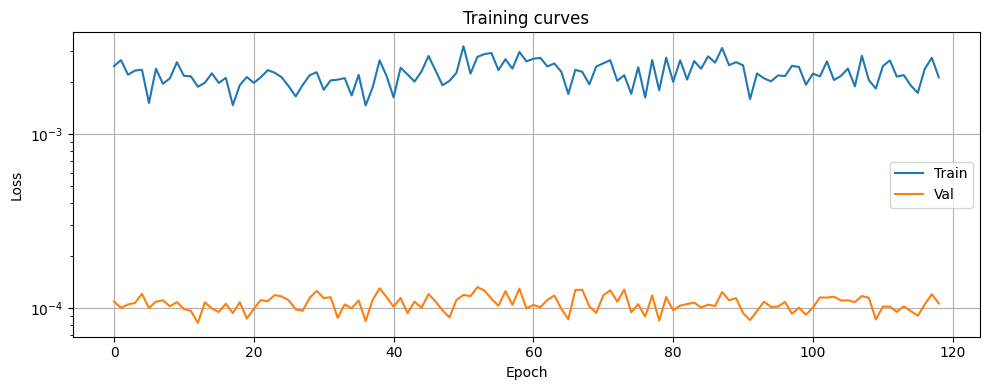

In [9]:
plot_losses(ep_recon, ep_commit)

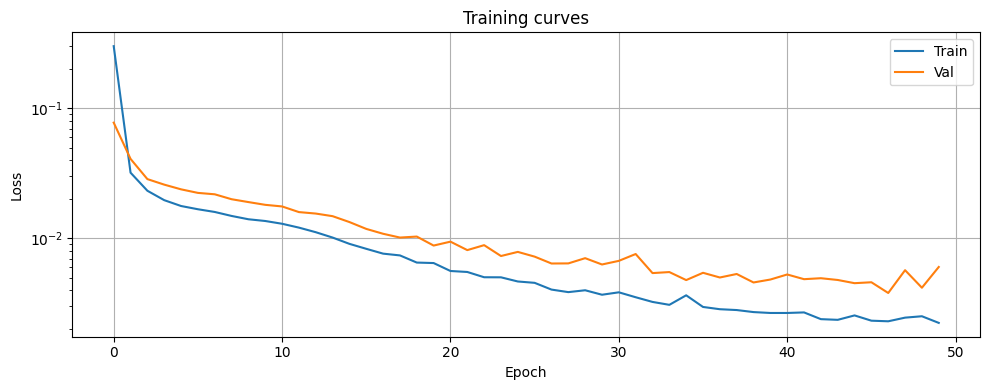

In [6]:
plot_losses(train_losses, val_losses)

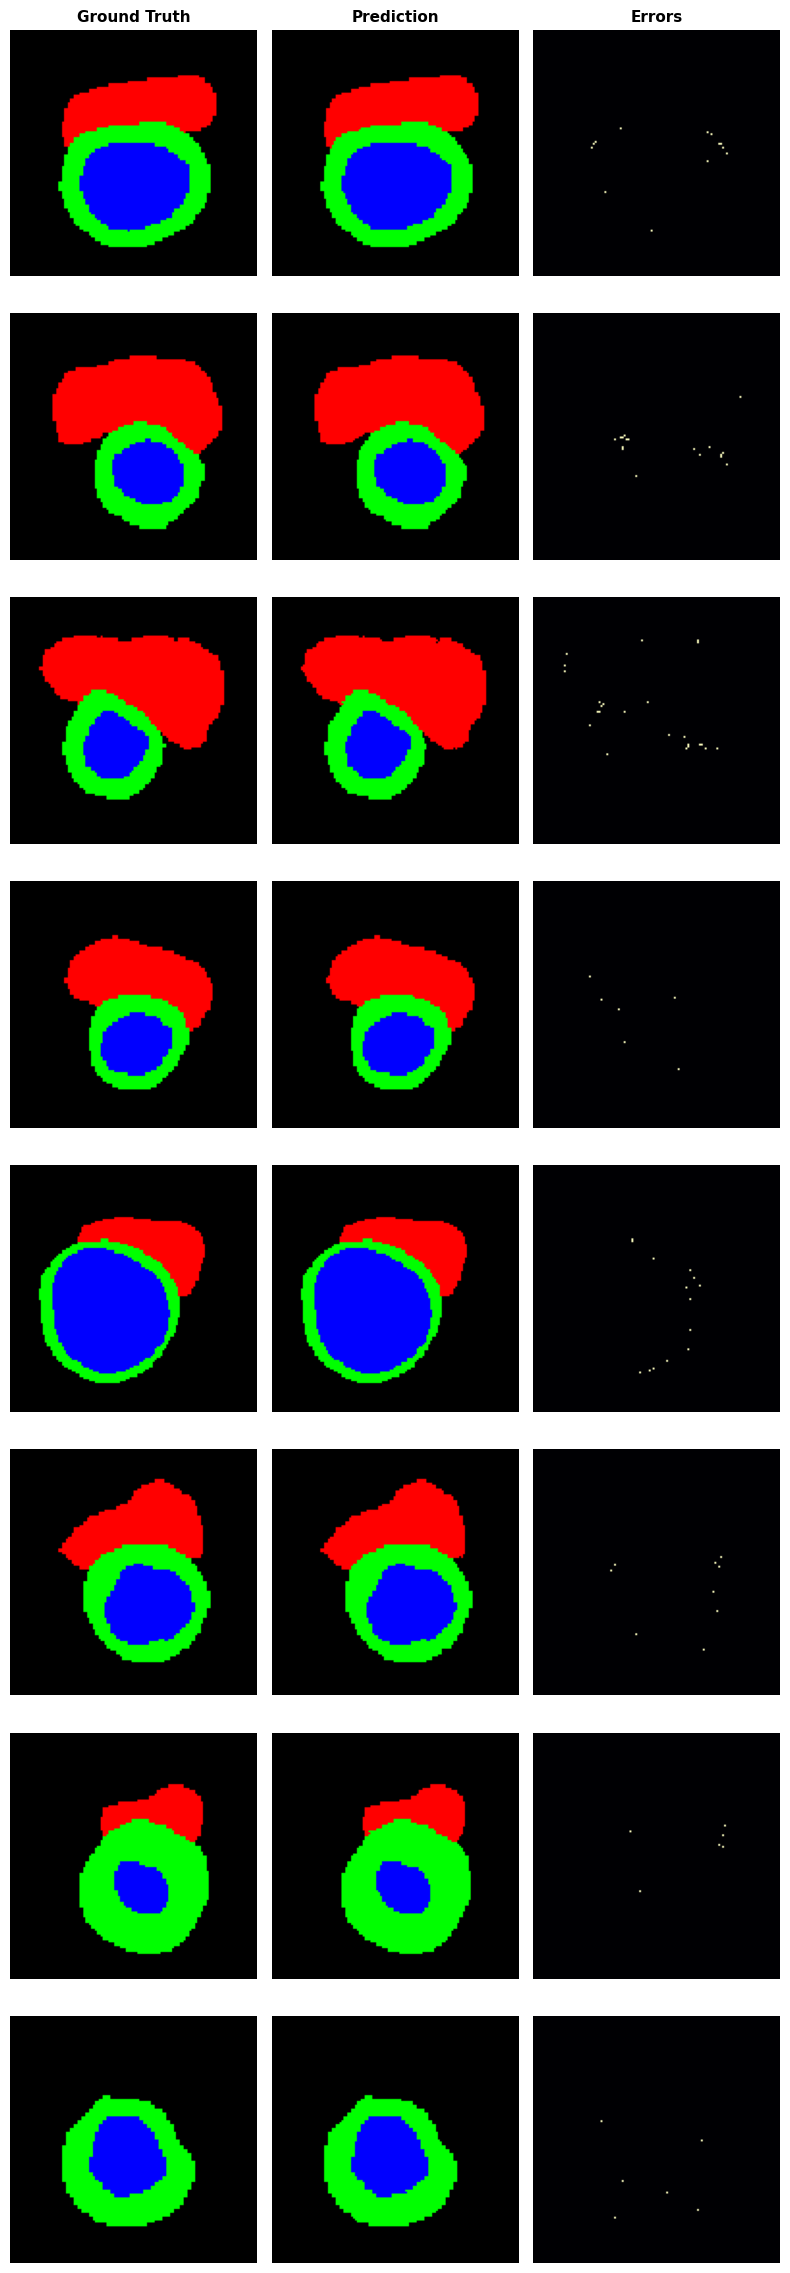

In [8]:
show_errors(x,y[0])